# Comparative Analysis of Machine Learning Classifiers for Medical Diagnosis

## Objective

The main goal of this assignment is to practice the complete machine learning process using a classification dataset. I used the Breast Cancer Wisconsin Diagnostic dataset, converted it into a Pandas DataFrame, checked the data, scaled the features, trained different models, and compared their performance. This helped me understand how machine learning models can be used for medical diagnosis problems.

In [1]:
# Importing necessary libraries for data handling, numerical computation, visualization, and machine learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importing the Breast Cancer Wisconsin Diagnostic dataset from scikit-learn
from sklearn.datasets import load_breast_cancer

# Importing tools for splitting data and scaling features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Importing classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Importing evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

## Dataset Loading

The Breast Cancer Wisconsin Diagnostic dataset is loaded from scikit-learn.

In [2]:
# Loading the Breast Cancer Wisconsin Diagnostic dataset
# The dataset is returned as a Bunch object

data = load_breast_cancer()

In [3]:
# Converting the raw Bunch object into a Pandas DataFrame
# The feature names from the dataset are used as column names

df = pd.DataFrame(data.data, columns=data.feature_names)

# Adding the target variable as a new column in the DataFrame
df['target'] = data.target

print("Target value counts:")
print(df['target'].value_counts())

print("\nTarget value percentage:")
print(df['target'].value_counts(normalize=True))

# Displaying the first five rows of the DataFrame
df.head()

Target value counts:
target
1    357
0    212
Name: count, dtype: int64

Target value percentage:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In this dataset, the target value 0 represents malignant tumors and 1 represents benign tumors. I checked the target distribution to see whether the dataset is balanced before training the models.

In [4]:
# Displaying basic information about the dataset

print("Dataset shape:", df.shape)
print("Number of features:", len(data.feature_names))
print("Target classes:", data.target_names)

Dataset shape: (569, 31)
Number of features: 30
Target classes: ['malignant' 'benign']


## Missing Value Check

Before training the models, I checked whether the dataset had any missing values. Missing values can create problems during model training, so this is an important step. In this dataset, no missing values were found.

In [5]:
# Checking for missing values in each column of the dataset

missing_values = df.isnull().sum()

# Displaying the number of missing values per column
missing_values

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

## Correlation Analysis

I used correlation analysis to find which features are most related to the target variable. This helped me identify the top five features that may be more useful for predicting whether a tumor is malignant or benign.

In [6]:
# Calculating the correlation matrix for all numerical columns
correlation_matrix = df.corr()

# Finding the top five features most correlated with the target variable
# The target column itself is excluded by using [1:6]
top_5_features = correlation_matrix['target'].abs().sort_values(ascending=False)[1:6]

# Displaying the top five correlated features
print("Top 5 features most correlated with the target variable:")
print(top_5_features)

Top 5 features most correlated with the target variable:
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
Name: target, dtype: float64


These features have the strongest relationship with the target variable. This helps to understand which measurements may be more useful for predicting whether a tumor is malignant or benign.

## Feature and Target Separation

The dataset is separated into input features and the target variable. The input features are used by the models to learn patterns, while the target variable contains the actual class labels.

In [7]:
# Separating the independent variables/features from the target variable
X = df.drop('target', axis=1)

# Separating the dependent variable/target
y = df['target']

In [8]:
# Splitting the dataset into training and testing sets
# 80% of the data is used for training and 20% is used for testing
# random_state is used to make the result reproducible

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

## Feature Scaling

In [9]:
# Creating an object of StandardScaler
scaler = StandardScaler()

# Fitting the scaler only on the training data and transforming the training data
# This prevents information from the test data from leaking into the training process
X_train_scaled = scaler.fit_transform(X_train)

# Transforming the test data using the same scaler fitted on the training data
X_test_scaled = scaler.transform(X_test)

## Model Training

For this assignment, I trained three classification models: Logistic Regression, Random Forest Classifier, and Support Vector Machine. I used the same training and testing data for all models so that their performance could be compared fairly.

In [10]:
# Creating a dictionary of machine learning models
# Logistic Regression is used as the baseline classifier
# Random Forest is used as an ensemble-based classifier
# SVM is used as the third classification algorithm

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

In [11]:
# Creating an empty list to store the performance results of each model
results = []

# Training and evaluating each model using a loop
for model_name, model in models.items():
    
    # Training the model using the scaled training data
    model.fit(X_train_scaled, y_train)
    
    # Predicting the target values for the test data
    y_pred = model.predict(X_test_scaled)
    
    # Calculating evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    # Storing the results in dictionary format
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall
    })

# Converting the results list into a Pandas DataFrame for better readability
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.982456,0.986111,0.986111
1,Random Forest,0.956140,0.958904,0.972222
2,Support Vector Machine,0.982456,0.986111,0.986111


## Model Comparison Visualization

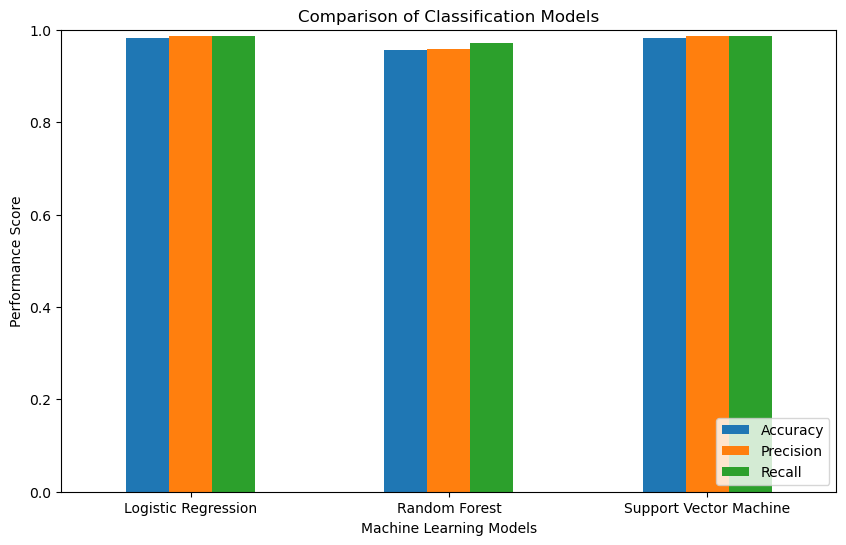

In [12]:
# Creating a bar chart to compare Accuracy, Precision, and Recall for all models
results_df.set_index("Model")[["Accuracy", "Precision", "Recall"]].plot(
    kind="bar",
    figsize=(10, 6)
)

# Adding chart title and axis labels
plt.title("Comparison of Classification Models")
plt.xlabel("Machine Learning Models")
plt.ylabel("Performance Score")

# Setting y-axis limit from 0 to 1 because metric scores range between 0 and 1
plt.ylim(0, 1)

# Rotating x-axis labels for better readability
plt.xticks(rotation=0)

plt.legend(loc="lower right")
plt.show()

## Confusion Matrix Using Matplotlib

The best-performing model is selected based on the highest accuracy score. In this case, Logistic Regression and Support Vector Machine gave the same highest accuracy, so the first one from the results table is used for the confusion matrix.

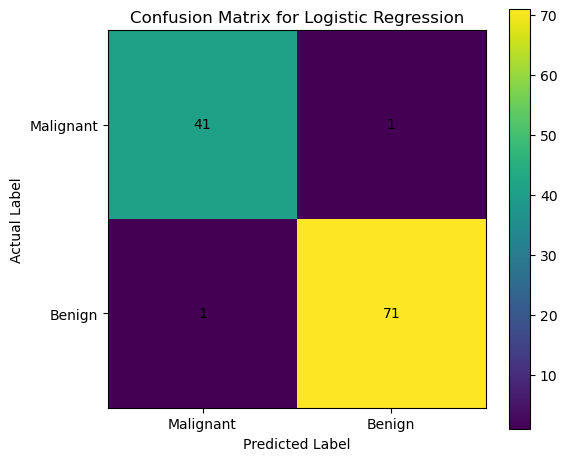

In [13]:
# Plotting the confusion matrix for the best-performing model using Matplotlib
best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

best_model_predictions = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, best_model_predictions)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest')
plt.title(f"Confusion Matrix for {best_model_name}")
plt.colorbar()

class_names = ["Malignant", "Benign"]
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# Adding numbers inside the confusion matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

The confusion matrix shows how many malignant and benign cases were correctly and incorrectly predicted. This is important in medical diagnosis because false predictions can affect treatment decisions.

## ROC Curve

The Receiver Operating Characteristic curve is used to evaluate the classification ability of a model at different threshold values.

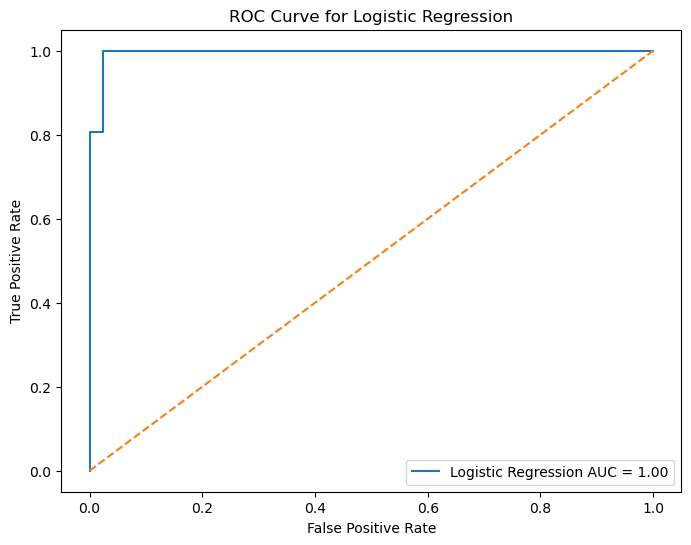

In [14]:
# Selecting Logistic Regression for ROC curve analysis
roc_model = models["Logistic Regression"]

# Getting the predicted probabilities for the positive class
y_prob = roc_model.predict_proba(X_test_scaled)[:, 1]

# Calculating False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculating the Area Under the Curve
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {roc_auc:.2f}")

# Plotting the diagonal reference line
plt.plot([0, 1], [0, 1], linestyle="--")

# Adding title, labels, and legend
plt.title("ROC Curve for Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.show()

## Conclusion

In this assignment, I worked with the Breast Cancer Wisconsin Diagnostic dataset and compared three machine learning models: Logistic Regression, Random Forest Classifier, and Support Vector Machine. Before training the models, I converted the dataset into a Pandas DataFrame, checked for missing values, scaled the features, and found the five features most correlated with the target variable.

After training and testing the models, I compared them using accuracy, precision, and recall. From the results, Logistic Regression and Support Vector Machine gave the same highest accuracy, so both models performed well on this dataset. I also used a confusion matrix to understand the prediction errors and plotted a ROC curve for Logistic Regression.

Overall, this project helped me understand the full workflow of a classification problem, from preprocessing to model evaluation. For a medical diagnosis task, evaluation metrics are especially important because wrong predictions can have serious consequences.